Student Proof Gap Analyzer

In [ ]:
#!/usr/bin/env python3
"""
Real profiles (n=6):       Extracted from AXOVRA ProofOps WhatsApp group chat,
                           Day 1 Drop, June 25-26, 2026.
Synthetic profiles (n=9):  Adjacent student archetypes (web dev, data analyst,
                           cloud/DevOps). Clearly marked. Do not represent real
                           individuals.
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import textwrap
import warnings

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
})

REAL_COLOR  = "#E07B54"
SYNTH_COLOR = "#7B9EC9"
ACCENT      = "#2C3E50"
OUT_DIR     = ""

In [ ]:
raw_data = [
    { #real data
        "student_id":           "R001",
        "name":                 "Parshvi Jain",
        "profile_type":         "real",
        "role_target":          "Applied AI / ML Engineer",
        "skill_category":       "AI/ML",
        "skills_claimed":       "Python, FastAPI, PyTorch, NLP, IEEE publication, IIT Madras BS",
        "proof_stated":         (
            "Deployed E2E AI product: trained model, FastAPI backend, frontend, "
            "explainable outputs, README with design tradeoffs and limitations"
        ),
        "proof_artifact_exists": False,
        "gap_type":             "Scope Overreach",
        "scope_score":          2,
    },
    {
        "student_id":           "R002",
        "name":                 "Mishthi Dutta",
        "profile_type":         "real",
        "role_target":          "AI/ML Engineer",
        "skill_category":       "AI/ML",
        "skills_claimed":       "Machine learning, data analysis, pattern recognition",
        "proof_stated":         (
            "ML model for antibiotic resistance prediction using ML techniques "
            "to analyze data and identify patterns related to resistance"
        ),
        "proof_artifact_exists": False,
        "gap_type":             "No Deployment Signal",
        "scope_score":          1,
    },
    {
        "student_id":           "R003",
        "name":                 "Satya Sourav Das",
        "profile_type":         "real",
        "role_target":          "Data Scientist / Data Analyst",
        "skill_category":       "Data Science",
        "skills_claimed":       "Data science, AI (implied by lane choice)",
        "proof_stated":         "Not stated ; submitted partial response, no proof field present",
        "proof_artifact_exists": False,
        "gap_type":             "Incomplete Submission",
        "scope_score":          1,
    },
    {
        "student_id":           "R004",
        "name":                 "Vaidehi Purohit",
        "profile_type":         "real",
        "role_target":          "AI/ML Engineer / SDE Intern",
        "skill_category":       "AI/ML + Full Stack",
        "skills_claimed":       "Python, ML, development and problem-solving skills",
        "proof_stated":         (
            "InterviewOS: DSA progress tracker, interview roadmap, resume checker, "
            "GitHub/project tracker, company-wise preparation dashboard, "
            "coding progress analytics, and DSA visualizations"
        ),
        "proof_artifact_exists": False,
        "gap_type":             "Vision-Artifact Confusion",
        "scope_score":          3,
    },
    {
        "student_id":           "R005",
        "name":                 "Shivang Saxena",
        "profile_type":         "real",
        "role_target":          "AI/ML Engineer",
        "skill_category":       "AI/ML + Full Stack",
        "skills_claimed":       "ML, intelligent assistance, full-stack architecture, secure authentication",
        "proof_stated":         (
            "Production-ready AI-powered women's safety and wellness platform: ML, "
            "health tracking, emergency response, secure auth, modern full-stack architecture"
        ),
        "proof_artifact_exists": False,
        "gap_type":             "Vision-Artifact Confusion",
        "scope_score":          3,
    },
    {
        "student_id":           "R006",
        "name":                 "Dnyaneshwari Yewale",
        "profile_type":         "real",
        "role_target":          "Data Analyst / AI/ML",
        "skill_category":       "Data Analytics",
        "skills_claimed":       "SQL, Python, Excel, Power BI, data analytics, visualization",
        "proof_stated":         (
            "InsightPulse: SQL-based data processing, Python-driven analysis, "
            "interactive Power BI dashboards, KPI tracking, trend analysis, "
            "and predictive insights"
        ),
        "proof_artifact_exists": False,
        "gap_type":             "Vision-Artifact Confusion",
        "scope_score":          3,
    }, #synthetic data
    {
        "student_id":           "S001",
        "name":                 "Synthetic: Arjun Mehta",
        "profile_type":         "synthetic",
        "role_target":          "Frontend / React Developer Intern",
        "skill_category":       "Web Dev",
        "skills_claimed":       "React, JavaScript, HTML, CSS, Tailwind",
        "proof_stated":         (
            "Full social media clone with authentication, real-time chat, "
            "notifications, and a recommendation feed"
        ),
        "proof_artifact_exists": False,
        "gap_type":             "Vision-Artifact Confusion",
        "scope_score":          3,
    },
    {
        "student_id":           "S002",
        "name":                 "Synthetic: Riya Sharma",
        "profile_type":         "synthetic",
        "role_target":          "Data Analyst Intern",
        "skill_category":       "Data Analytics",
        "skills_claimed":       "Excel, SQL, Power BI",
        "proof_stated":         "Excel sales dashboard built and complete, saved locally on laptop",
        "proof_artifact_exists": False,
        "gap_type":             "No Deployment Signal",
        "scope_score":          1,
    },
    {
        "student_id":           "S003",
        "name":                 "Synthetic: Karan Verma",
        "profile_type":         "synthetic",
        "role_target":          "Backend Developer / Node.js Intern",
        "skill_category":       "Web Dev",
        "skills_claimed":       "Node.js, Express, MongoDB, REST APIs",
        "proof_stated":         "Claims Node.js experience but has nothing hosted or published",
        "proof_artifact_exists": False,
        "gap_type":             "Skill-Claim Without Anchor",
        "scope_score":          1,
    },
    {
        "student_id":           "S004",
        "name":                 "Synthetic: Ananya Gupta",
        "profile_type":         "synthetic",
        "role_target":          "Cloud / DevOps Intern",
        "skill_category":       "Cloud / DevOps",
        "skills_claimed":       "AWS basics, Linux, Docker, GitHub Actions",
        "proof_stated":         (
            "Microservices e-commerce app on Kubernetes with full CI/CD pipeline, "
            "monitoring, alerting, and auto-scaling"
        ),
        "proof_artifact_exists": False,
        "gap_type":             "Scope Overreach",
        "scope_score":          3,
    },
    {
        "student_id":           "S005",
        "name":                 "Synthetic: Rohan Patel",
        "profile_type":         "synthetic",
        "role_target":          "Data Analyst Intern",
        "skill_category":       "Data Analytics",
        "skills_claimed":       "Python, Pandas, Matplotlib, SQL",
        "proof_stated":         (
            "EDA notebook on Kaggle housing dataset with charts and a written "
            "insights doc ; notebook exists locally, not published"
        ),
        "proof_artifact_exists": False,
        "gap_type":             "No Deployment Signal",
        "scope_score":          1,
    },
    {
        "student_id":           "S006",
        "name":                 "Synthetic: Neha Joshi",
        "profile_type":         "synthetic",
        "role_target":          "ML Engineer Intern",
        "skill_category":       "AI/ML",
        "skills_claimed":       "Python, scikit-learn, TensorFlow, Jupyter",
        "proof_stated":         "LinkedIn bio says Machine Learning Enthusiast ; no project or repo linked",
        "proof_artifact_exists": False,
        "gap_type":             "Skill-Claim Without Anchor",
        "scope_score":          1,
    },
    {
        "student_id":           "S007",
        "name":                 "Synthetic: Saurabh Singh",
        "profile_type":         "synthetic",
        "role_target":          "DevOps Engineer Intern",
        "skill_category":       "Cloud / DevOps",
        "skills_claimed":       "Jenkins, Docker, Git, Linux, GitHub Actions",
        "proof_stated":         (
            "CI/CD pipeline set up for a sample hello-world app ; "
            "stored in a private GitHub repo, not documented or shared"
        ),
        "proof_artifact_exists": False,
        "gap_type":             "No Deployment Signal",
        "scope_score":          2,
    },
    {
        "student_id":           "S008",
        "name":                 "Synthetic: Priya Das",
        "profile_type":         "synthetic",
        "role_target":          "Full Stack Developer Intern",
        "skill_category":       "Web Dev",
        "skills_claimed":       "React, Node.js, MongoDB, REST APIs, CSS",
        "proof_stated":         (
            "A to-do app deployed on Vercel and a weather app ; "
            "both are tutorial-level builds, no real problem solved"
        ),
        "proof_artifact_exists": True,
        "gap_type":             "Role-Proof Mismatch",
        "scope_score":          1,
    },
    {
        "student_id":           "S009",
        "name":                 "Synthetic: Akash Tiwari",
        "profile_type":         "synthetic",
        "role_target":          "Data Scientist Intern",
        "skill_category":       "Data Science",
        "skills_claimed":       "Python, ML, SQL, Tableau",
        "proof_stated":         (
            "Plans to build a recommendation engine, a fraud detection system, "
            "an NLP sentiment tool, and a real-time stock price predictor"
        ),
        "proof_artifact_exists": False,
        "gap_type":             "Scope Overreach",
        "scope_score":          3,
    },
]

df = pd.DataFrame(raw_data)

print(f"\n  Total profiles   : {len(df)}")
print(f"  Real             : {(df['profile_type']=='real').sum()}")
print(f"  Synthetic        : {(df['profile_type']=='synthetic').sum()}")
print(f"  Artifact exists  : {df['proof_artifact_exists'].sum()} of {len(df)}\n")
print("  Gap Type Distribution:")
for gap, count in df['gap_type'].value_counts().items():
    print(f"    {gap:<30} {count}")
print()
print(df[['student_id', 'profile_type', 'skill_category',
          'gap_type', 'scope_score', 'proof_artifact_exists']].to_string(index=False))




  Total profiles   : 15
  Real             : 6
  Synthetic        : 9
  Artifact exists  : 1 of 15

  Gap Type Distribution:
    No Deployment Signal           4
    Vision-Artifact Confusion      4
    Scope Overreach                3
    Skill-Claim Without Anchor     2
    Incomplete Submission          1
    Role-Proof Mismatch            1

student_id profile_type     skill_category                   gap_type  scope_score  proof_artifact_exists
      R001         real              AI/ML            Scope Overreach            2                  False
      R002         real              AI/ML       No Deployment Signal            1                  False
      R003         real       Data Science      Incomplete Submission            1                  False
      R004         real AI/ML + Full Stack  Vision-Artifact Confusion            3                  False
      R005         real AI/ML + Full Stack  Vision-Artifact Confusion            3                  False
      R006     

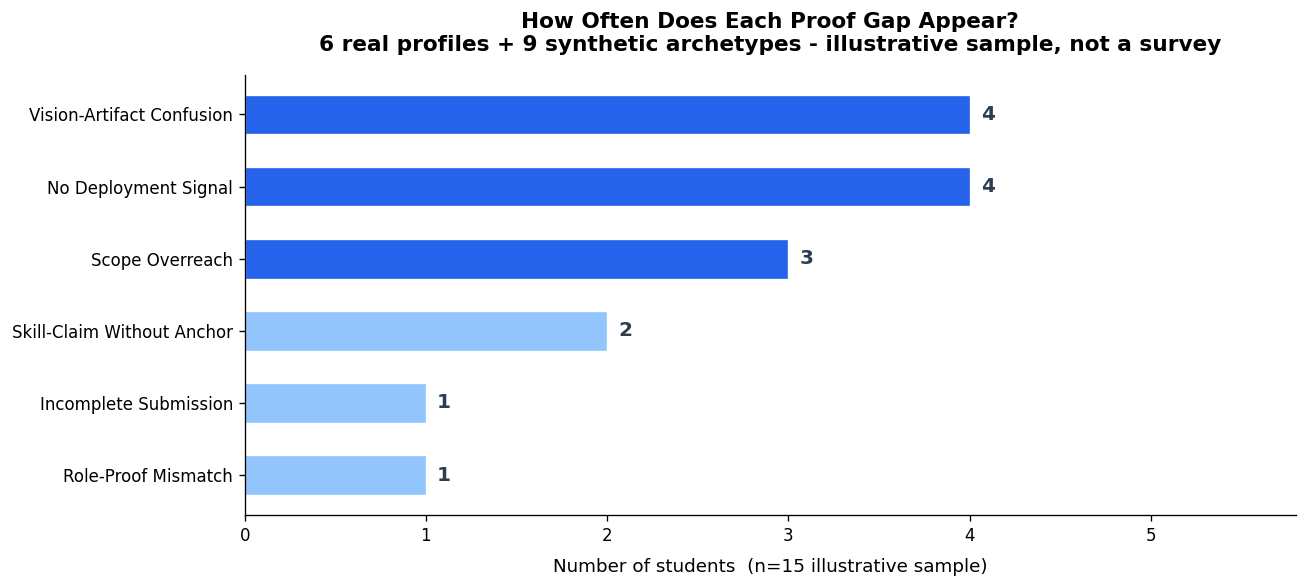

Saved: fig1_gap_frequency.png



In [ ]:
gap_counts = df['gap_type'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 5))

bar_colors = ["#2563EB" if v >= 3 else "#93C5FD" for v in gap_counts.values]
bars = ax.barh(
    gap_counts.index,
    gap_counts.values,
    color=bar_colors,
    edgecolor="white",
    linewidth=0.8,
    height=0.55,
)

for bar, val in zip(bars, gap_counts.values):
    ax.text(
        val + 0.06,
        bar.get_y() + bar.get_height() / 2,
        str(val),
        va="center", ha="left",
        fontsize=12, color=ACCENT, fontweight="bold",
    )

ax.set_xlabel("Number of students  (n=15 illustrative sample)", fontsize=11, labelpad=8)
ax.set_title(
    "How Often Does Each Proof Gap Appear?\n"
    "6 real profiles + 9 synthetic archetypes - illustrative sample, not a survey",
    fontsize=13, fontweight="bold", pad=14,
)
ax.set_xlim(0, gap_counts.max() + 1.8)
ax.tick_params(axis="y", labelsize=10)
ax.tick_params(axis="x", labelsize=10)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(f"{OUT_DIR}fig1_gap_frequency.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig1_gap_frequency.png\n")

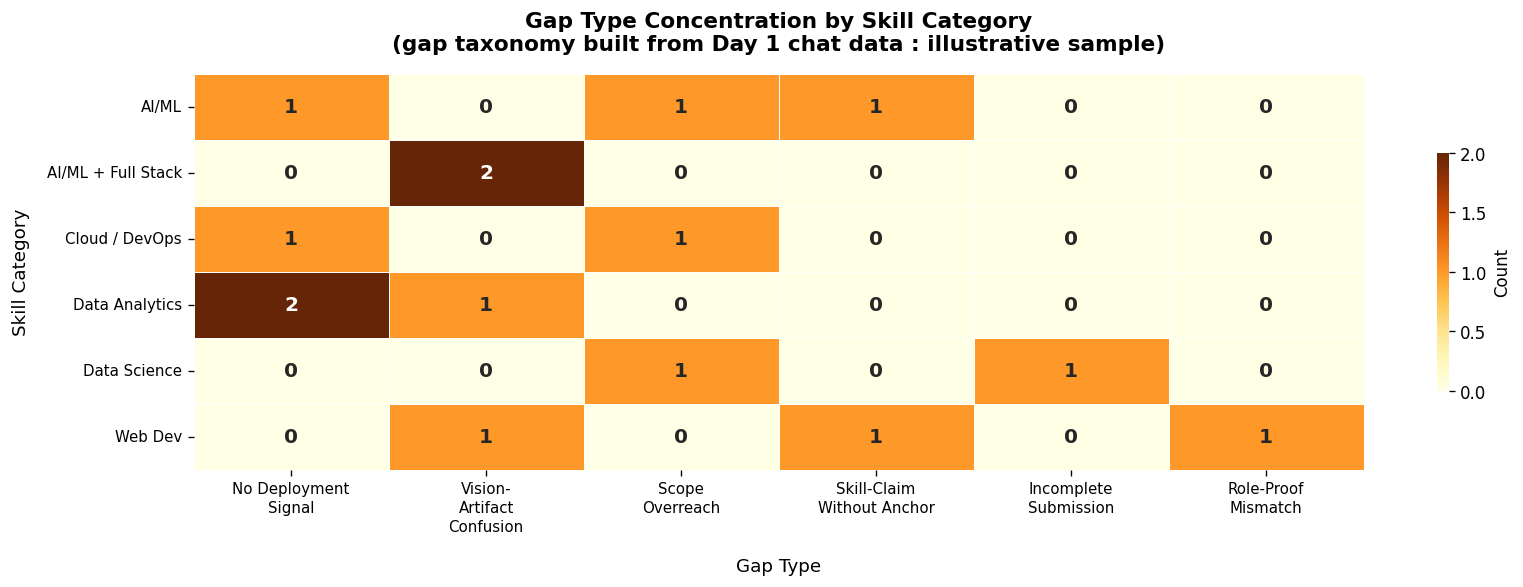

Saved: fig2_gap_heatmap.png



In [ ]:

heatmap_data = (
    df.groupby(["skill_category", "gap_type"])
    .size()
    .unstack(fill_value=0)
)
col_order = [c for c in df["gap_type"].value_counts().index if c in heatmap_data.columns]
heatmap_data = heatmap_data[col_order]

fig, ax = plt.subplots(figsize=(14, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    cmap="YlOrBr",
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    annot_kws={"size": 12, "weight": "bold"},
    cbar_kws={"shrink": 0.6, "label": "Count"},
)

# Wrap long column labels to prevent overlap
wrapped_x = [textwrap.fill(c, 14) for c in heatmap_data.columns]
ax.set_xticklabels(wrapped_x, rotation=0, ha="center", fontsize=9, linespacing=1.3)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.set_xlabel("Gap Type", fontsize=11, labelpad=14)
ax.set_ylabel("Skill Category", fontsize=11, labelpad=10)
ax.set_title(
    "Gap Type Concentration by Skill Category\n"
    "(gap taxonomy built from Day 1 chat data : illustrative sample)",
    fontsize=13, fontweight="bold", pad=14,
)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}fig2_gap_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig2_gap_heatmap.png\n")


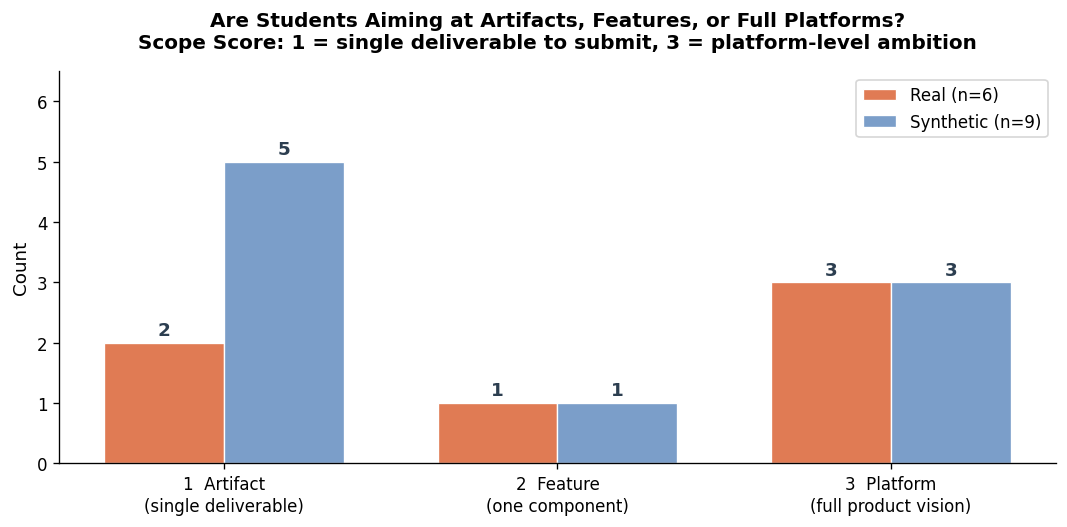

Saved: fig3_scope_distribution.png



In [ ]:

scope_labels = {
    1: "1  Artifact\n(single deliverable)",
    2: "2  Feature\n(one component)",
    3: "3  Platform\n(full product vision)",
}
df["scope_label"] = df["scope_score"].map(scope_labels)

scope_by_type = (
    df.groupby(["scope_label", "profile_type"])
    .size()
    .unstack(fill_value=0)
)
ordered = [scope_labels[i] for i in [1, 2, 3]]
scope_by_type = scope_by_type.reindex(ordered)

fig, ax = plt.subplots(figsize=(9, 4.5))
x     = np.arange(len(scope_by_type))
width = 0.36

real_vals  = scope_by_type.get("real",      pd.Series(0, index=scope_by_type.index)).values
synth_vals = scope_by_type.get("synthetic", pd.Series(0, index=scope_by_type.index)).values

bars_r = ax.bar(x - width / 2, real_vals,  width, label="Real (n=6)",
                color=REAL_COLOR,  edgecolor="white", linewidth=0.8)
bars_s = ax.bar(x + width / 2, synth_vals, width, label="Synthetic (n=9)",
                color=SYNTH_COLOR, edgecolor="white", linewidth=0.8)

for bar in list(bars_r) + list(bars_s):
    h = bar.get_height()
    if h > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2, h + 0.06,
            str(int(h)), ha="center", va="bottom",
            fontsize=11, fontweight="bold", color=ACCENT,
        )

ax.set_xticks(x)
ax.set_xticklabels(scope_by_type.index, fontsize=10, linespacing=1.3)
ax.set_ylabel("Count", fontsize=11)
ax.set_title(
    "Are Students Aiming at Artifacts, Features, or Full Platforms?\n"
    "Scope Score: 1 = single deliverable to submit, 3 = platform-level ambition",
    fontsize=12, fontweight="bold", pad=14,
)
ax.legend(fontsize=10)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.set_ylim(0, max(max(real_vals), max(synth_vals)) + 1.5)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}fig3_scope_distribution.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig3_scope_distribution.png\n")


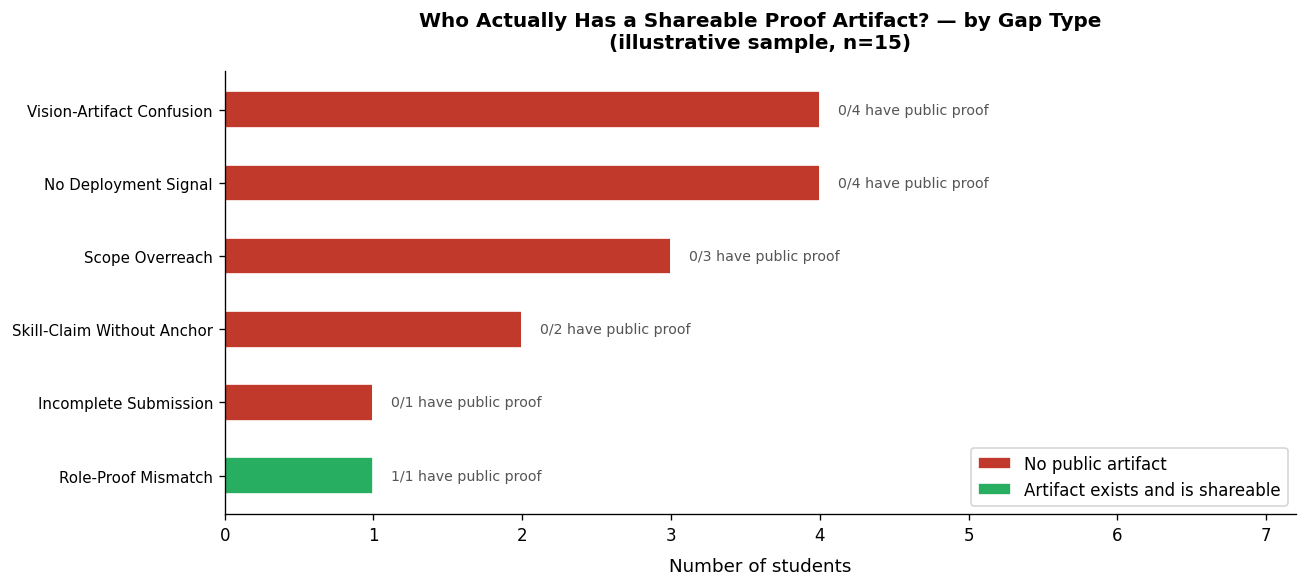

Saved: fig4_artifact_exists.png



In [ ]:
agg = df.groupby("gap_type")["proof_artifact_exists"].agg(["sum", "count"])
agg.columns = ["has_artifact", "total"]
agg["no_artifact"] = agg["total"] - agg["has_artifact"]
agg = agg.sort_values("no_artifact", ascending=True)

fig, ax = plt.subplots(figsize=(11, 5))
y_pos = np.arange(len(agg))

ax.barh(y_pos, agg["no_artifact"],
        color="#C0392B", label="No public artifact",
        edgecolor="white", height=0.5)
ax.barh(y_pos, agg["has_artifact"],
        left=agg["no_artifact"],
        color="#27AE60", label="Artifact exists and is shareable",
        edgecolor="white", height=0.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(agg.index, fontsize=9)

for i, (_, row) in enumerate(agg.iterrows()):
    label = f"{int(row['has_artifact'])}/{int(row['total'])} have public proof"
    ax.text(row["total"] + 0.12, i, label, va="center", fontsize=8.5, color="#555")

ax.set_xlabel("Number of students", fontsize=11, labelpad=8)
ax.set_xlim(0, agg["total"].max() + 3.2)
ax.set_title(
    "Who Actually Has a Shareable Proof Artifact? ; by Gap Type\n"
    "(illustrative sample, n=15)",
    fontsize=12, fontweight="bold", pad=14,
)
ax.legend(fontsize=10, loc="lower right")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}fig4_artifact_exists.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig4_artifact_exists.png\n")


INSIGHTS:
1. Vision-Artifact Confusion
2.  Platform-Level Scope Always Pairs With Zero Artifacts
3. Submission Completeness Predicts Proof Readiness
4. Dual-Lane Role Targeting Inflates Scope Score
5. No Deployment Signal is the Most Fixable Gap in This Set

**What Should AXOVRA Help Students Build First?**
The dominant finding is not a skill gap. Skills exist. The dominant finding is
a framing gap. Students interpret "proof" as "product I plan to build," not as
"artifact a recruiter can open right now." Until that framing is corrected,
technical workshops on Python, SQL, or ML will not improve proof conversion.

The first AXOVRA intervention should ask one question at intake:

  "If your recruiter opened your proof today, what specific URL or
  file would they see and what would it show them?"

Students who cannot answer that question with something real need framing
help before they need skill help. That is what this data says.
